In [1]:
from Plot import plot_flatmap_cortical_activation, plot_flatmap_cerebellar_activation
import os
import globals as gl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nibabel as nb
import  numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap
import pyvista as pv

import nitools as nt
plt.style.use('default')

# Define the updated function and test it on the provided file
def load_border_vertices_xml(filepath):
    vertices = []
    inside_vertices_block = False
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if "<Vertices>" in line:
                inside_vertices_block = True
                line = line.replace("<Vertices>", "")
            if inside_vertices_block:
                if "</Vertices>" in line:
                    line = line.replace("</Vertices>", "")
                    inside_vertices_block = False
                if line:
                    numbers = [int(x) for x in line.split()]
                    vertices.extend(numbers)
    return np.array(vertices)

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


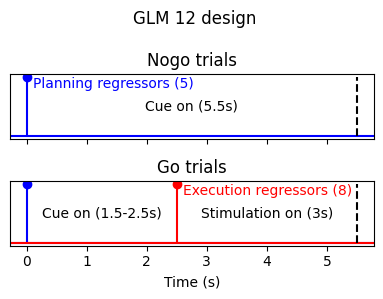

In [2]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, figsize=(4, 3))

axs[0].axhline(0, color='blue')
axs[0].stem(0, 1, linefmt='b-', )
axs[0].set_title('Nogo trials')
axs[0].vlines(5.5, 0, 1,  color='k', ls='--')
axs[0].text(2.75, .5, 'Cue on (5.5s)', ha='center', va='center')
axs[0].text(.1, 1, 'Planning regressors (5)', ha='left', va='top', color='blue')
axs[0].set_yticks([])

axs[1].axhline(0, color='blue')
axs[1].stem(0, 1, linefmt='b-')
axs[1].set_title('Go trials')
axs[1].axhline(0, color='red')
axs[1].stem(2.5, 1, linefmt='r-')
axs[1].vlines(5.5, 0, 1,  color='k', ls='--')
axs[1].set_yticks([])
axs[1].text(1.25, .5, 'Cue on (1.5-2.5s)', ha='center', va='center')
axs[1].text(4, .5, 'Stimulation on (3s)', ha='center', va='center')
axs[1].text(2.6, 1, 'Execution regressors (8)', ha='left', va='top', color='red')
axs[1].set_xlabel('Time (s)')

fig.suptitle(f'GLM 12 design')
fig.tight_layout()


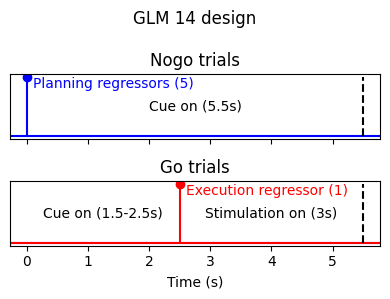

In [3]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, figsize=(4, 3))

axs[0].axhline(0, color='blue')
axs[0].stem(0, 1, linefmt='b-', )
axs[0].set_title('Nogo trials')
axs[0].vlines(5.5, 0, 1,  color='k', ls='--')
axs[0].text(2.75, .5, 'Cue on (5.5s)', ha='center', va='center')
axs[0].text(.1, 1, 'Planning regressors (5)', ha='left', va='top', color='blue')
axs[0].set_yticks([])

axs[1].axhline(0, color='blue')
axs[1].set_title('Go trials')
axs[1].axhline(0, color='red')
axs[1].stem(2.5, 1, linefmt='r-')
axs[1].vlines(5.5, 0, 1,  color='k', ls='--')
axs[1].set_yticks([])
axs[1].text(1.25, .5, 'Cue on (1.5-2.5s)', ha='center', va='center')
axs[1].text(4, .5, 'Stimulation on (3s)', ha='center', va='center')
axs[1].text(2.6, 1, 'Execution regressor (1)', ha='left', va='top', color='red')
axs[1].set_xlabel('Time (s)')

fig.suptitle(f'GLM 14 design')
fig.tight_layout()

/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


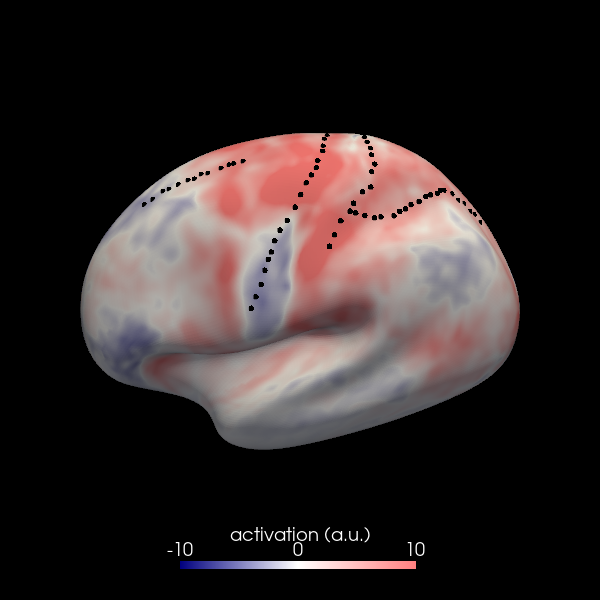

In [4]:
experiment = 'smp2'
glm = 14
dtype = 'con'
Hem = ['L']

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

for h, H in enumerate(Hem):

    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
    data = nt.get_gifti_data_matrix(giftis[0])[:, -1]
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    if H=='L':
        sulc = sulc[:len(data)]
    else:
        sulc = sulc[len(data):]

    # Now create the mesh
    mesh = pv.PolyData(coords, faces)
    mesh.point_data["overlay"] = data

    mesh.point_data["sulc"] = sulc

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")
    borderIPS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")
    borderCS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")
    borderPoCS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")
    borderSF = coords[border_verts]

    p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
    p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
    p.add_scalar_bar(title="activation (a.u.)",
                 n_labels=3,                 # Show fewer ticks
                 vertical=False,            # Horizontal layout
                 color='w',
                 shadow=True,
                 fmt="%.0f",
                 position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
                 position_y=0.05, # Lower position (closer to bottom of figure)
                 width=0.4,       # Proportion of figure width
                 height=0.04)
    p.add_points(borderCS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderPoCS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderIPS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderSF[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("black")
p.view_vector((-1, 0, .5))        # start from a good view
 # dorsal view


p.show()

/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


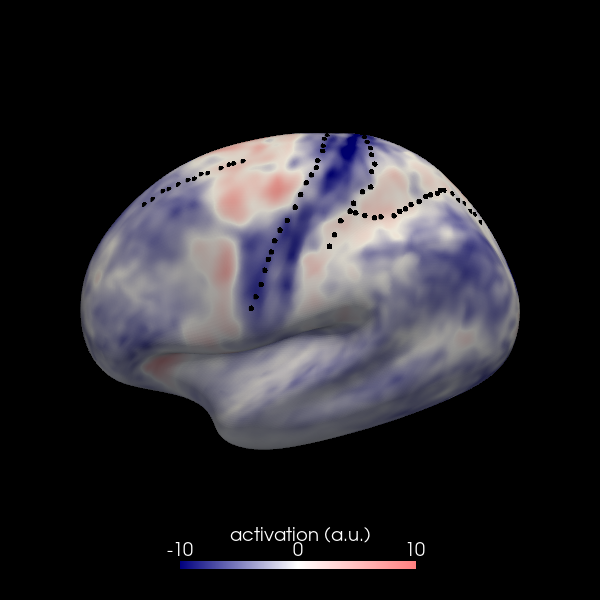

In [5]:
import pyvista as pv
import nibabel as nb
import numpy as np
import os
import globals as gl
import nitools as nt

experiment = 'smp2'
glm = 14
dtype = 'con'
Hem = ['L']

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

for h, H in enumerate(Hem):

    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
    data = nt.get_gifti_data_matrix(giftis[0])[:, :-1].mean(axis=-1)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    if H=='L':
        sulc = sulc[:len(data)]
    else:
        sulc = sulc[len(data):]

    # Now create the mesh
    mesh = pv.PolyData(coords, faces)
    mesh.point_data["overlay"] = data

    mesh.point_data["sulc"] = sulc

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")
    borderIPS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")
    borderCS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")
    borderPoCS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")
    borderSF = coords[border_verts]

    p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
    p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
    p.add_scalar_bar(title="activation (a.u.)",
                 n_labels=3,                 # Show fewer ticks
                 vertical=False,            # Horizontal layout
                 color='w',
                 shadow=True,
                 fmt="%.0f",
                 position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
                 position_y=0.05, # Lower position (closer to bottom of figure)
                 width=0.4,       # Proportion of figure width
                 height=0.04)
    p.add_points(borderCS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderPoCS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderIPS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderSF[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("black")
p.view_vector((-1, 0, .5))        # start from a good view
 # dorsal view


p.show()

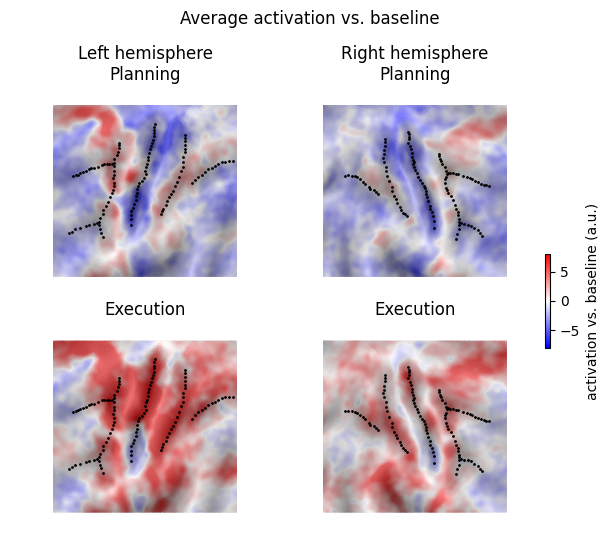

In [6]:
plt.style.use('default')

glm = 14
experiment='smp2'
dtype = 'con'

img = os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.smooth.dscalar.nii')

fig, axs = plot_flatmap_cortical_activation(img, vmin=-8, vmax=8, figsize=(6, 6), frame=(.16, .12, .68, .8), rounding=0, cbar_fraction=.01)

fig.suptitle(f'Average activation vs. baseline')
fig.subplots_adjust(top=0.85, bottom=.1, wspace=0, hspace=0.1, right=.9, left=0)

plt.show()

In [7]:
# glm = 12
# experiment='smp2'
# dtype = 'con'
#
# img = os.path.join(gl.baseDir, experiment, 'SUIT', f'glm{glm}.{dtype}.flat.surf.gii')
#
# fig, axs = plot_flatmap_cerebellar_activation(img, vmin=-8, vmax=8, figsize=(8, 6), cbar_fraction=.01)
#
# fig.suptitle(f'Average activation vs. baseline')
# fig.subplots_adjust(top=0.85, bottom=.1, wspace=0, hspace=0.1, right=.9, left=0)
#
# plt.show()

In [8]:
# glm = 12
# experiment = 'smp2'
# rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
# H = 'L'
# conditions = list(gl.regressor_mapping.keys())[0:13]
#
# df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
# df_con['sn'] = df_con['sn'].astype(str)
# df_con = df_con[df_con['condition'].isin(conditions)]
# df_con = df_con.groupby(['condition', 'roi', 'Hem', 'sn']).mean(numeric_only=True).reset_index()
#
# fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(14, 5))
#
# for r, roi in enumerate(rois):
#
#     sns.boxplot(df_con[(df_con['roi'] == roi) & (df_con['Hem'] == H)],
#                 ax=axs[r],
#                 y='con',
#                 x='condition',
#                 order=conditions,
#                 palette=[gl.colour_mapping[cond] for cond in conditions],
#                 showfliers=False,
#                 legend=False
#                 )
#
#     axs[r].axhline(0, ls='-', color='k', lw=.8)
#     axs[r].set_title(roi)
#     axs[r].set_ylabel('')
#     axs[r].set_xlabel('')
#     axs[r].set_xticks(axs[r].get_xticks())
#     axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=90)
#
# fig.supylabel('activation (a.u.)')
# fig.suptitle(f'Average planning activity across participants (N={len(df_con.sn.unique())}), hemisphere:{H}')
# fig.tight_layout()